# Business Problem
 Swiggy processes millions of food-delivery journeys across hundreds of cities every month. Accurate Estimated Time of Arrival (ETA) at order placement and during delivery is core to the customer experience — it affects conversion, cancellations, ratings, and retention. Today’s ETA accuracy suffers from many sources of uncertainty: highly variable traffic patterns, weather events, restaurant preparation variability, rider behaviour and skill, order batching/multiple deliveries, and city-specific operational constraints. Inaccurate ETAs cause:
- Reduced customer trust and lower repeat orders.


- Increased cancellations and refund costs.


- Higher support volume and operational interventions.


- Sub-optimal rider allocation and increased rider idle or overtime costs.


# Problem Statement
Swiggy’s objective is to predict the delivery time (minutes) per order at the moment of order placement (and update it dynamically), with business-grade accuracy and uncertainty estimates so the platform can
 -  show reliable ETAs to customers
 -  optimize rider allocation.
 
Build a production-ready, scalable Machine Learning system that predicts per-order delivery time (in minutes) using real-time and historical features (order, rider, restaurant, geospatial, traffic, weather, and temporal signals). The system must produce:


# CRISP-ML(Q) Methodology

## 1. Business & Data Understanding:

| Column Name              | Description                                                                   |
| ------------------------ | ----------------------------------------------------------------------------- |
| **Rider_id**             | Unique identifier for each delivery partner                                   |
| **Age**                  | Age of the delivery partner                                                   |
| **Ratings**              | Average customer rating of the rider                                          |
| **vehicle_condition**    | Condition of the rider’s vehicle (0 = Poor, 1 = Average, 2 = Good)            |
| **Type_of_vehicle**      | Vehicle used for delivery (motorcycle, scooter, etc.)                         |
| **Type_of_order**        | Type of food ordered (snack, meal, drinks, buffet)                            |
| **multiple_deliveries**  | Number of deliveries assigned to the rider in a single trip                   |
| **pickup_time_minutes**  | Time taken by the restaurant to prepare the order (in minutes)                |
| **restaurant_longitude** | Geographic longitude of the restaurant                                        |
| **delivery_longitude**   | Geographic longitude of the customer’s delivery location                      |
| **Is_weekend**           | Indicates whether the order was placed on a weekend (Yes/No or 1/0)           |
| **Order_time_hour**      | Hour when the order was placed (0–23)                                         |
| **order_time_of_day**    | Time bucket of the order (morning, afternoon, evening, night)                 |
| **Weather**              | Weather condition during delivery (sunny, cloudy, fog, stormy, sandstorms)    |
| **Traffic**              | Traffic condition during delivery (low, medium, high, jam)                    |
| **Festival**             | Indicates whether the order was placed on a festival day (Yes/No)             |
| **City_type**            | Classification of city (urban, metropolitan)                                  |
| **City_name**            | Name/code of the city (BANG, HYD, CHEN, etc.)                                 |
| **Time_taken**           | Actual time taken to complete the delivery (in minutes) → **Target variable** |
| **Distance**             | Distance between restaurant and delivery location (in km)                     |
| **Order_date**           | Date when the order was placed                                                |
| **Order_day**            | Day of the month                                                              |
| **Order_month**          | Month of the order                                                            |
| **order_day_of_week**    | Day of the week (Monday–Sunday)                                               |


## 2. Data Preprocessing

In [1]:
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\srira\Downloads\swiggy_demographic.csv")
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


In [3]:
df.shape

(45502, 26)

In [4]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [5]:
df.dtypes

rider_id                 object
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date               object
weather                  object
traffic                  object
vehicle_condition         int64
type_of_order            object
type_of_vehicle          object
multiple_deliveries     float64
festival                 object
city_type                object
time_taken                int64
city_name                object
order_day                 int64
order_month               int64
order_day_of_week        object
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day        object
distance                float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [7]:
df.describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [8]:
df.isna().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
data = ['restaurant_latitude','restaurant_longitude','delivery_latitude','delivery_longitude','distance']
df = df.dropna(subset=data)

In [11]:
df['age'] = df.groupby(by = 'rider_id')['age'].transform(lambda x : x.fillna(x.mean()))

In [12]:
df['ratings'] = df.groupby(by = 'rider_id')['ratings'].transform(lambda x : x.fillna(x.mean()))

In [13]:
df['city_type'] = df.groupby('city_name')['city_type'].transform(lambda x: x.fillna(x.mode()[0]))

In [14]:
df['weather'].fillna(df['weather'].mode()[0], inplace=True)

In [15]:
df['traffic'].fillna(df['traffic'].mode()[0], inplace=True)

In [16]:
df['festival'].fillna(df['festival'].mode()[0],inplace=True)

In [17]:
df['multiple_deliveries'].fillna(df['multiple_deliveries'].median(),inplace=True)

In [18]:
df['pickup_time_minutes'].unique()

array([15.,  5., 10., nan])

In [19]:
a = [15.0,5.0,10.0]
df['pickup_time_minutes'].fillna(random.choices(a)[0],inplace=True)

In [20]:
df['order_time_hour'] = df.groupby('order_time_of_day')['order_time_hour'].transform(lambda x : x.fillna(x.median()))

In [21]:
df.isna().sum()

rider_id                0
age                     0
ratings                 0
restaurant_latitude     0
restaurant_longitude    0
delivery_latitude       0
delivery_longitude      0
order_date              0
weather                 0
traffic                 0
vehicle_condition       0
type_of_order           0
type_of_vehicle         0
multiple_deliveries     0
festival                0
city_type               0
time_taken              0
city_name               0
order_day               0
order_month             0
order_day_of_week       0
is_weekend              0
pickup_time_minutes     0
order_time_hour         0
order_time_of_day       0
distance                0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41872 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              41872 non-null  object 
 1   age                   41872 non-null  float64
 2   ratings               41872 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            41872 non-null  object 
 8   weather               41872 non-null  object 
 9   traffic               41872 non-null  object 
 10  vehicle_condition     41872 non-null  int64  
 11  type_of_order         41872 non-null  object 
 12  type_of_vehicle       41872 non-null  object 
 13  multiple_deliveries   41872 non-null  float64
 14  festival              41872 non-null  object 
 15  city_type             41

In [23]:
df.shape

(41872, 26)

###  column removal Using Domain Knowdledge

In [24]:
df.drop(columns=['rider_id','order_date','restaurant_latitude','restaurant_longitude','delivery_latitude','delivery_longitude'],inplace=True)

In [25]:
df.select_dtypes(include='object').columns

Index(['weather', 'traffic', 'type_of_order', 'type_of_vehicle', 'festival',
       'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day'],
      dtype='object')

# Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
categorical = ['weather', 'type_of_order', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day']
df_trans = pd.DataFrame()
ohe = OneHotEncoder(dtype='int',drop='first')
for i in categorical:
    df_1 = pd.DataFrame(ohe.fit_transform(df[[i]]).todense(),columns=ohe.get_feature_names_out())
    df_trans = pd.concat((df_trans,df_1),axis=1)

In [28]:
df_trans

,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,type_of_order_meal,type_of_order_snack,type_of_vehicle_electric_scooter,type_of_vehicle_motorcycle,...,order_day_of_week_monday,order_day_of_week_saturday,order_day_of_week_sunday,order_day_of_week_thursday,order_day_of_week_tuesday,order_day_of_week_wednesday,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night
0,0,0,0,1,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,1,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0
3,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41867,0,0,0,0,1,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
41868,0,0,0,0,1,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,0
41869,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
41870,0,0,0,0,0,0,0,1,0,1,...,1,0,0,0,0,0,1,0,0,0


In [29]:
from sklearn.preprocessing import OrdinalEncoder

In [30]:
order = [['low','medium','high','jam']]
ord = OrdinalEncoder(dtype='int',categories=order)
df_2 = pd.DataFrame(ord.fit_transform(df[['traffic']]),columns=ord.get_feature_names_out())
df_trans = pd.concat((df_trans,df_2),axis=1)

In [31]:
df.reset_index(inplace=True)
df_trans.reset_index(inplace=True)
df_trans

,index,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,type_of_order_meal,type_of_order_snack,type_of_vehicle_electric_scooter,...,order_day_of_week_saturday,order_day_of_week_sunday,order_day_of_week_thursday,order_day_of_week_tuesday,order_day_of_week_wednesday,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic
0,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,2
1,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,3
2,2,0,1,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
3,3,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
4,4,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41867,41867,0,0,0,0,1,1,0,0,0,...,0,0,0,1,0,0,0,0,1,3
41868,41868,0,0,0,0,1,0,1,0,0,...,0,0,1,0,0,0,0,1,0,2
41869,41869,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
41870,41870,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,2


In [32]:
df.drop(columns=['weather', 'type_of_order', 'type_of_vehicle', 'festival', 'city_type', 'city_name', 'order_day_of_week', 'order_time_of_day','traffic'],inplace=True)

In [33]:
df_main = pd.concat((df,df_trans),axis=1)
df_main.drop(columns='index',inplace=True)

In [34]:
df_main

,age,ratings,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,...,order_day_of_week_saturday,order_day_of_week_sunday,order_day_of_week_thursday,order_day_of_week_tuesday,order_day_of_week_wednesday,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic
0,37.0,4.9,2,0.0,24,19,3,1,15.0,11.0,...,1,0,0,0,0,0,0,1,0,2
1,34.0,4.5,2,1.0,33,25,3,0,5.0,19.0,...,0,0,0,0,0,0,1,0,0,3
2,23.0,4.4,0,1.0,26,19,3,1,15.0,8.0,...,1,0,0,0,0,0,0,1,0,0
3,38.0,4.7,0,1.0,21,5,4,0,10.0,18.0,...,0,0,0,1,0,0,1,0,0,1
4,32.0,4.6,1,1.0,30,26,3,1,15.0,13.0,...,1,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41867,35.0,4.2,2,1.0,33,8,3,0,10.0,21.0,...,0,0,0,1,0,0,0,0,1,3
41868,30.0,4.8,1,0.0,32,24,3,0,10.0,11.0,...,0,0,1,0,0,0,0,1,0,2
41869,30.0,4.9,1,0.0,16,11,3,0,15.0,23.0,...,0,0,0,0,0,0,0,0,1,0
41870,20.0,4.7,0,1.0,26,7,3,0,5.0,13.0,...,0,0,0,0,0,1,0,0,0,2


## Feature Scaling

In [35]:
scale = ['age','ratings','vehicle_condition','multiple_deliveries','order_day','order_month','pickup_time_minutes','order_time_hour','distance','traffic']

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

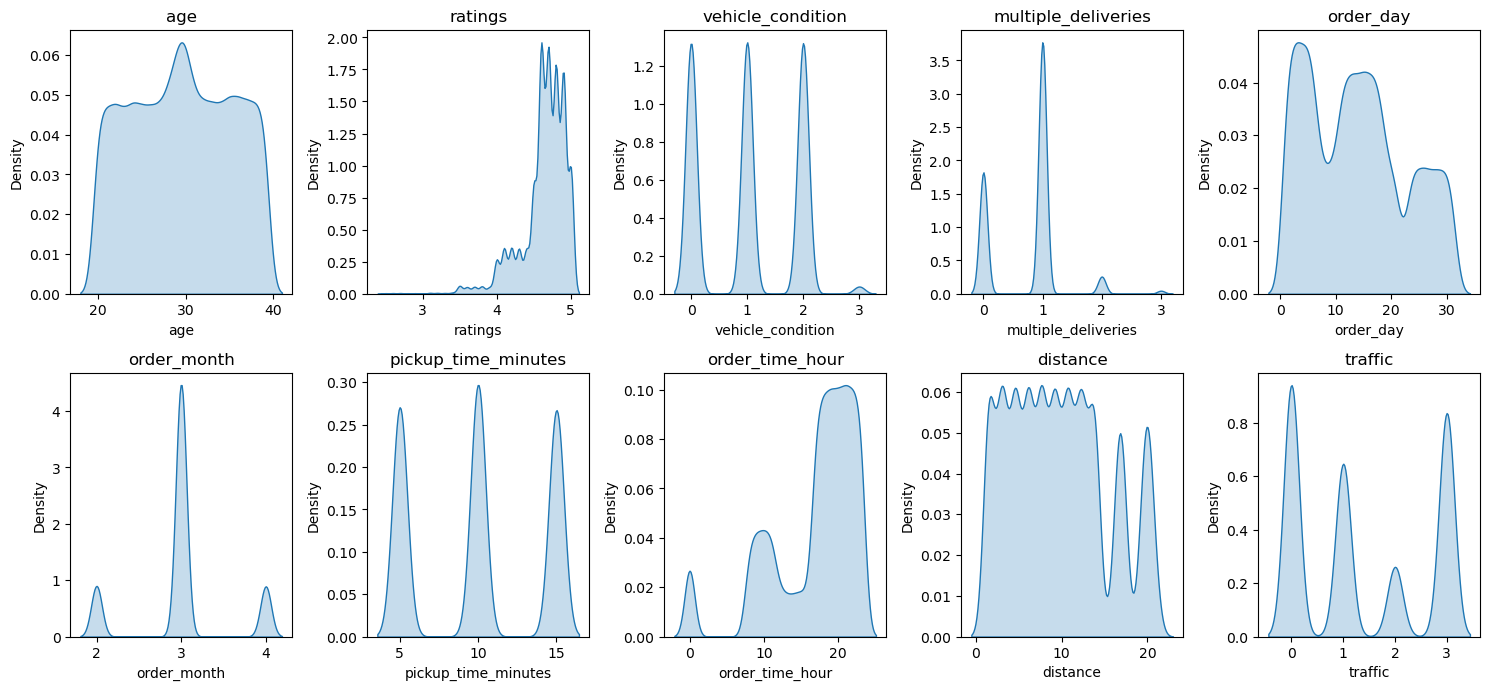

In [37]:
plt.figure(figsize=(15,10))
for i in range(1,11):
    plt.subplot(3,5,i)
    col = scale[i-1]
    sns.kdeplot(x=df_main[col],fill=True)
    plt.title(col)
plt.tight_layout()

In [38]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
for i in scale:
    df_main[i]= st.fit_transform(df_main[[i]])

In [39]:
df_main

,age,ratings,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,...,order_day_of_week_saturday,order_day_of_week_sunday,order_day_of_week_thursday,order_day_of_week_tuesday,order_day_of_week_wednesday,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic
0,1.319323,0.862557,1.174743,-1.324130,24,0.592030,0.002145,1,1.251237,-1.008401,...,1,0,0,0,0,0,0,1,0,0.505085
1,0.787874,-0.434527,1.174743,0.439075,33,1.275316,0.002145,0,-1.241000,0.385042,...,0,0,0,0,0,0,1,0,0,1.306514
2,-1.160773,-0.758798,-1.219981,0.439075,26,0.592030,0.002145,1,1.251237,-1.530942,...,1,0,0,0,0,0,0,1,0,-1.097774
3,1.496473,0.214015,-1.219981,0.439075,21,-1.002303,1.873089,0,0.005119,0.210862,...,0,0,0,1,0,0,1,0,0,-0.296344
4,0.433574,-0.110256,-0.022619,0.439075,30,1.389197,0.002145,1,1.251237,-0.660040,...,1,0,0,0,0,1,0,0,0,0.505085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41867,0.965024,-1.407340,1.174743,0.439075,33,-0.660660,0.002145,0,0.005119,0.733403,...,0,0,0,1,0,0,0,0,1,1.306514
41868,0.079275,0.538286,-0.022619,-1.324130,32,1.161435,0.002145,0,0.005119,-1.008401,...,0,0,1,0,0,0,0,1,0,0.505085
41869,0.079275,0.862557,-0.022619,-1.324130,16,-0.319017,0.002145,0,1.251237,1.081764,...,0,0,0,0,0,0,0,0,1,-1.097774
41870,-1.692222,0.214015,-1.219981,0.439075,26,-0.774541,0.002145,0,-1.241000,-0.660040,...,0,0,0,0,0,1,0,0,0,0.505085


# Feature Selection

In [40]:
a = df_main.corr()['time_taken']

In [41]:
a[abs(a) > 0.1]

age                           0.296061
ratings                      -0.354097
vehicle_condition            -0.235347
multiple_deliveries           0.377980
time_taken                    1.000000
order_time_hour               0.148566
distance                      0.320705
weather_fog                   0.125043
weather_sunny                -0.206035
type_of_vehicle_motorcycle    0.162823
type_of_vehicle_scooter      -0.136160
festival_yes                  0.288844
city_type_semi-urban          0.148783
city_type_urban              -0.186619
order_time_of_day_evening     0.153202
order_time_of_day_morning    -0.241165
traffic                       0.412039
Name: time_taken, dtype: float64

In [42]:
from sklearn.feature_selection import f_regression,SelectKBest

In [43]:
x = df_main.drop(columns=['time_taken'])
y = df_main['time_taken']

In [44]:
kbest = SelectKBest(f_regression)
kbest.fit_transform(x,y)

array([[ 1.31932301,  0.86255722,  1.17474252, ...,  1.        ,
         1.        ,  0.50508493],
       [ 0.78787388, -0.43452685,  1.17474252, ...,  0.        ,
         0.        ,  1.30651417],
       [-1.16077296, -0.75879786, -1.21998101, ...,  1.        ,
         1.        , -1.09777355],
       ...,
       [ 0.07927503,  0.86255722, -0.02261925, ...,  0.        ,
         0.        , -1.09777355],
       [-1.69222209,  0.21401518, -1.21998101, ...,  0.        ,
         0.        ,  0.50508493],
       [-1.16077296,  0.86255722,  1.17474252, ...,  0.        ,
         0.        , -0.29634431]], shape=(41872, 10))

In [45]:
kbest.get_feature_names_out()

array(['age', 'ratings', 'vehicle_condition', 'multiple_deliveries',
       'distance', 'weather_sunny', 'festival_yes', 'city_type_urban',
       'order_time_of_day_morning', 'traffic'], dtype=object)

In [46]:
kbest.scores_

array([4.02258602e+03, 6.00249233e+03, 2.45509291e+03, 6.97899011e+03,
       2.47001159e+01, 4.93964023e+00, 1.83078014e+00, 3.67960529e+00,
       9.45006644e+02, 4.80009530e+03, 6.65068373e+02, 1.77730166e+01,
       1.67007906e+01, 1.85619321e+03, 3.24040721e+00, 2.00291277e+00,
       5.26508380e+00, 1.07357731e-02, 1.44980189e+02, 1.14026440e+03,
       7.90913936e+02, 3.81121214e+03, 9.47833534e+02, 1.51080418e+03,
       7.55018199e+00, 1.85008506e+00, 2.45105701e+00, 8.67890819e-01,
       1.49991064e-01, 1.23762010e-03, 5.98394269e-01, 3.36646009e-01,
       5.05268978e-01, 1.60167392e+00, 6.33319508e+00, 1.60025339e-01,
       6.96508829e-03, 1.71232873e-02, 5.27388094e-02, 2.82037058e+00,
       3.06958918e+00, 2.42194380e-02, 1.61138932e-01, 2.07638731e+00,
       2.23366675e+00, 5.17747806e-01, 8.85553942e+00, 1.52040155e+00,
       8.13724688e+01, 5.91195311e+01, 1.86080003e+02, 2.10035113e+01,
       1.00634508e+03, 2.58556264e+03, 1.68910275e+02, 8.56218643e+03])

In [47]:
from sklearn.feature_selection import mutual_info_regression

In [48]:
mi_scores = mutual_info_regression(x, y, random_state=23)

In [49]:
selected_features = x.columns[mi_scores > 0.05]
X_selected = x[selected_features]
X_selected.columns

Index(['age', 'ratings', 'vehicle_condition', 'multiple_deliveries',
       'order_day', 'order_time_hour', 'distance', 'traffic'],
      dtype='object')

In [50]:
final_features = ['age','ratings','vehicle_condition','multiple_deliveries','distance','traffic','festival_yes','order_time_hour','order_time_of_day_morning','weather_sunny','city_type_urban']

In [51]:
x=df_main[final_features]
y=df_main['time_taken']

# Model Building

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=23)

In [54]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)    
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.5554546960332003

In [55]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
r2_score(y_test,y_pred)

0.44237861646633103

In [59]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
r2_score(y_test,y_pred)

0.6976490134823408

In [60]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
r2_score(y_test,y_pred)

0.6543856529587004

In [61]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(x_train, y_train)
y_pred = lasso.predict(x_test)
r2_score(y_test, y_pred)

0.5555515653978453

In [56]:
from xgboost import XGBRegressor
xg = XGBRegressor()
xg.fit(x_train,y_train)
y_pred = xg.predict(x_test)
r2_score(y_test,y_pred)

0.7212113738059998

In [57]:
xg.fit(x,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
rf.fit(x,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Cross Validation

In [63]:
from sklearn.model_selection import KFold,cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=23)
cross_val_score(estimator=rf,X = x,y=y,scoring='r2',cv = kf).mean()

np.float64(0.6938820872660519)

In [58]:
from sklearn.model_selection import KFold,cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=23)
cross_val_score(estimator=xg,X = x,y=y,scoring='r2',cv = kf).mean()

np.float64(0.720520269870758)

# Hyper Parameter Tuning

In [64]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': np.arange(200, 600, 100),
    'max_depth': np.arange(10, 30, 5),
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rand_search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=20,cv=5,scoring='r2',n_jobs=-1,random_state=42,verbose=1)
rand_search.fit(x, y)

print("Best R2:", rand_search.best_score_)
print("Best Params:", rand_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best R2: 0.7302192782051748
Best Params: {'n_estimators': np.int64(200), 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': np.int64(15)}


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(rf,param_grid,cv=5,scoring='r2',n_jobs=-1,verbose=1)
grid.fit(x, y)

print("Best R2:", grid.best_score_)
print("Best Params:", grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best R2: 0.7295144841193928
Best Params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}


In [59]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Hyperparameter space (XGBoost-specific)
param_dist = {
    'n_estimators': np.arange(200, 600, 100),
    'max_depth': np.arange(3, 10),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

# Base XGBoost model
xg = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Randomized Search
rand_search = RandomizedSearchCV(
    estimator=xg,
    param_distributions=param_dist,
    n_iter=20,          
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit on full data (same as your RF code)
rand_search.fit(x, y)

# Results
print("Best R2:", rand_search.best_score_)
print("Best Params:", rand_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best R2: 0.728583812713623
Best Params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': np.int64(300), 'max_depth': np.int64(9), 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}


In [66]:
from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

final_rf.fit(x, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
import pickle

with open('swiggy_delivery_time_rf.pkl', 'wb') as file:
    pickle.dump(final_rf, file)


In [68]:
final_features = [
    'age',
    'ratings',
    'vehicle_condition',
    'multiple_deliveries',
    'distance',
    'traffic',
    'festival_yes',
    'order_time_hour',
    'order_time_of_day_morning',
    'weather_sunny',
    'city_type_urban'
]

with open('final_features.pkl', 'wb') as f:
    pickle.dump(final_features, f)